# Multiple Linear Regression – Student Performance Prediction

## Objective

The objective of this project is to build a **Multiple Linear Regression** model to predict a student's **Final Score** based on multiple factors such as:

- Study Hours
- Attendance
- Previous Score
- Sleep Hours

The project covers the complete Machine Learning workflow, including:

1. Loading the dataset
2. Exploratory Data Analysis (EDA)
3. Data cleaning
4. Handling missing values
5. Handling duplicate records
6. Data visualization
7. Correlation analysis
8. Feature selection
9. Train-test splitting
10. Building a Multiple Linear Regression model
11. Making predictions
12. Evaluating the model
13. Checking underfitting and overfitting
14. Saving the trained model

---

## What is Multiple Linear Regression?

Multiple Linear Regression is a **supervised machine learning regression algorithm** used to predict a **continuous numerical value** using **two or more independent variables (features)**.

Unlike Simple Linear Regression, which uses only one independent variable, Multiple Linear Regression uses multiple features to predict the target variable.

### Example

Suppose we want to predict a student's final exam score.

The student's final score may depend on:

- How many hours they study
- Their attendance percentage
- Their previous exam score
- Their average sleep hours

The model learns the relationship between these input variables and the final score.

```text
Study Hours ────────┐
Attendance ────────┤
Previous Score ────┼──→ Multiple Linear Regression → Final Score
Sleep Hours ───────┘

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Dataset

The Student Performance dataset contains information about students' study habits, attendance, previous academic performance, and sleep hours.

The target variable is **FinalScore**, which we want to predict using the other features.

In [27]:
# Load the dataset

df = pd.read_csv("Student_Performance.csv")

# Display the first 5 rows
df.head()

,StudyHours,Attendance,PreviousScore,SleepHours,FinalScore
0,4.0,85.0,53.3,7.1,57.8
1,8.6,78.1,69.4,6.9,73.5
2,6.9,68.3,84.3,5.1,73.7
3,5.8,90.0,78.0,6.4,76.3
4,2.2,84.4,81.3,6.5,70.1


# Understanding the Dataset

Before performing data cleaning and model building, we need to understand the structure of the dataset.

We will check:

- Number of rows and columns
- Column names
- Data types
- Statistical summary

In [28]:
# Check the number of rows and columns

print("Number of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows    : 505
Number of Columns : 5


In [29]:
# Display column names

print(df.columns)

Index(['StudyHours', 'Attendance', 'PreviousScore', 'SleepHours',
       'FinalScore'],
      dtype='str')


In [30]:
# Check dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StudyHours     503 non-null    float64
 1   Attendance     504 non-null    float64
 2   PreviousScore  504 non-null    float64
 3   SleepHours     504 non-null    float64
 4   FinalScore     504 non-null    float64
dtypes: float64(5)
memory usage: 19.9 KB


In [31]:
# Statistical summary

df.describe()

,StudyHours,Attendance,PreviousScore,SleepHours,FinalScore
count,503.000000,504.000000,504.000000,504.00000,504.000000
mean,4.988270,75.857143,68.271230,6.97877,66.835119
std,2.383192,12.283993,13.327894,1.15130,9.010576
min,1.000000,55.200000,45.200000,5.00000,40.500000
25%,2.900000,64.975000,56.050000,6.00000,61.300000
50%,5.100000,75.350000,69.250000,7.00000,67.300000
75%,7.000000,86.425000,79.825000,7.90000,73.425000
max,8.900000,98.000000,90.000000,9.00000,93.100000


# Data Cleaning

Data cleaning is an important step in Machine Learning because real-world datasets may contain:

- Missing values
- Duplicate records
- Incorrect data types
- Invalid values
- Outliers

Before training the model, we need to identify and handle these problems.

In [32]:
# Check for missing values

df.isnull().sum()

StudyHours       2
Attendance       1
PreviousScore    1
SleepHours       1
FinalScore       1
dtype: int64

## Handling Missing Values

Missing values can cause problems during Machine Learning model training.

For example, if a student's `StudyHours` is missing, the model cannot directly use that row for training.

Common methods for handling missing values are:

1. Remove rows containing missing values.
2. Replace missing values with the mean.
3. Replace missing values with the median.
4. Replace missing values with the mode.

### Which method should we use?

For numerical columns:

- **Mean** → useful when data has no significant outliers.
- **Median** → useful when data may contain outliers.
- **Mode** → mainly used for categorical data.

In this project, we will use the **median** to fill missing numerical values because it is less affected by extreme values.

In [33]:
# Fill missing values using the median

df["StudyHours"] = df["StudyHours"].fillna(df["StudyHours"].median())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].median())
df["PreviousScore"] = df["PreviousScore"].fillna(df["PreviousScore"].median())
df["SleepHours"] = df["SleepHours"].fillna(df["SleepHours"].median())
df["FinalScore"] = df["FinalScore"].fillna(df["FinalScore"].median())

In [34]:
# Check for missing values

df.isnull().sum()

StudyHours       0
Attendance       0
PreviousScore    0
SleepHours       0
FinalScore       0
dtype: int64

## Handling Duplicate Values

Duplicate records are repeated rows in a dataset.

Duplicate data can give extra importance to the same observation and may affect the Machine Learning model.

Therefore, we should identify and remove duplicate records before training the model.

In [35]:
# Check the number of duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5


In [36]:
# Remove duplicate rows

df = df.drop_duplicates()

In [37]:
print("Number of duplicate rows after removal:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

Number of duplicate rows after removal: 0
Dataset shape after cleaning: (500, 5)


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining and understanding a dataset before building a Machine Learning model.

In this project, we will use EDA to:

- Understand the distribution of the features.
- Identify relationships between variables.
- Detect unusual values.
- Understand which features may influence the target variable.

In [38]:
# Display the first 5 rows of the cleaned dataset

df.head()

,StudyHours,Attendance,PreviousScore,SleepHours,FinalScore
0,4.0,85.0,53.3,7.1,57.8
1,8.6,78.1,69.4,6.9,73.5
2,6.9,68.3,84.3,5.1,73.7
3,5.8,90.0,78.0,6.4,76.3
4,2.2,84.4,81.3,6.5,70.1


In [39]:
# Display statistical summary

df.describe()

,StudyHours,Attendance,PreviousScore,SleepHours,FinalScore
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,4.981800,75.759300,68.287500,6.985600,66.796000
std,2.383386,12.250474,13.372472,1.149537,9.033056
min,1.000000,55.200000,45.200000,5.000000,40.500000
25%,2.900000,64.900000,55.850000,6.000000,61.275000
50%,5.100000,75.325000,69.275000,7.000000,67.300000
75%,7.000000,86.225000,79.950000,7.900000,73.425000
max,8.900000,98.000000,90.000000,9.000000,93.100000


## Checking for Outliers

An outlier is a value that is unusually high or low compared with the majority of the observations.

Outliers can sometimes affect Linear Regression because the model tries to find the best-fitting line across all observations.

We will use boxplots to visually inspect the numerical features for possible outliers.

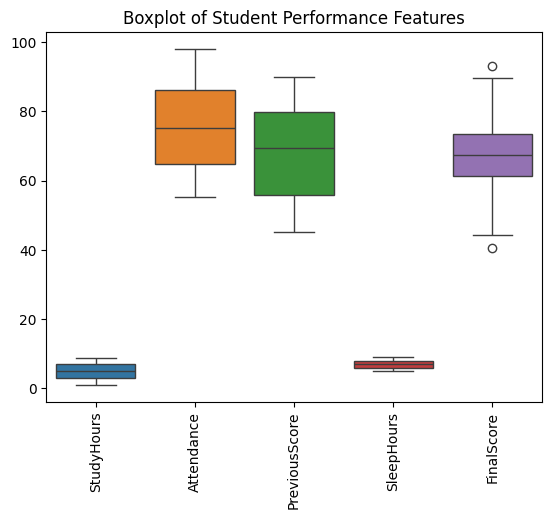

In [40]:
# Create boxplots for numerical features

sns.boxplot(data=df)
plt.title("Boxplot of Student Performance Features")
plt.xticks(rotation=90)
plt.show()

Text(0, 0.5, 'Final Score')

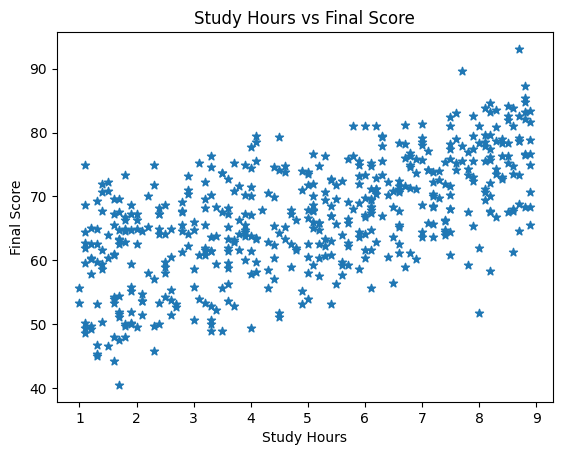

In [41]:
plt.scatter(
    df["StudyHours"],
    df["FinalScore"],
    marker="*"
)

plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final Score')

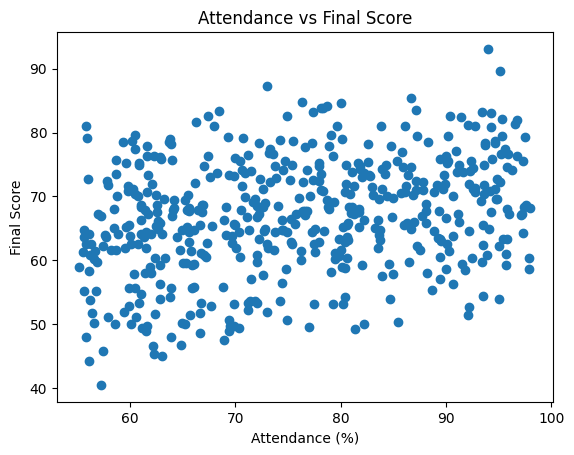

In [42]:
plt.scatter(
    df["Attendance"],
    df["FinalScore"],
    marker="o"
)

plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final Score')

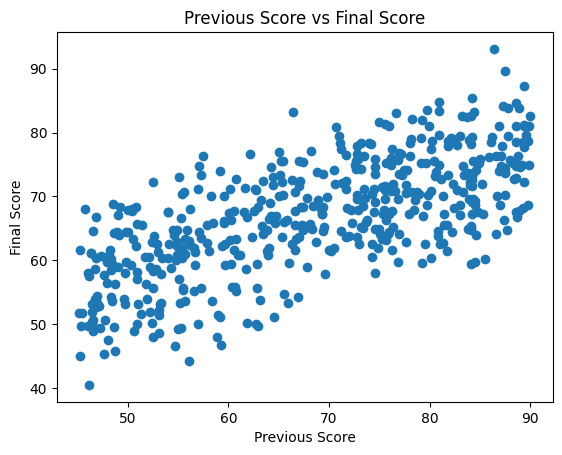

In [43]:
plt.scatter(
    df["PreviousScore"],
    df["FinalScore"],
    marker="o"
)

plt.title("Previous Score vs Final Score")
plt.xlabel("Previous Score")
plt.ylabel("Final Score")

Text(0, 0.5, 'Final Score')

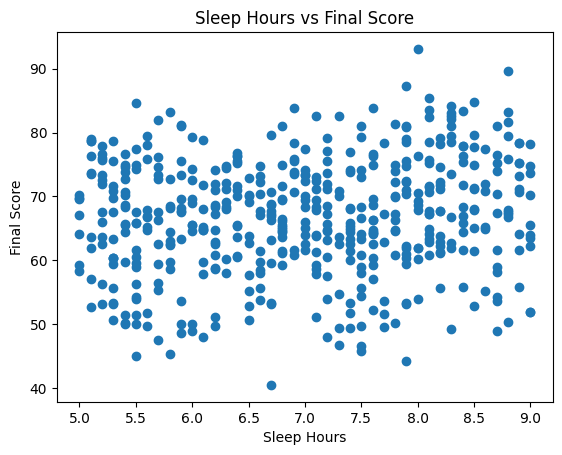

In [44]:
plt.scatter(
    df["SleepHours"],
    df["FinalScore"],
    marker="o"
)

plt.title("Sleep Hours vs Final Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Final Score")

# Correlation Analysis

Correlation measures the strength and direction of the linear relationship between two numerical variables.

The correlation coefficient ranges from **-1 to +1**.

- **+1** → Perfect positive correlation
- **0** → No linear correlation
- **-1** → Perfect negative correlation

### Why do we need correlation?

Correlation helps us understand:

- Which features have a strong relationship with the target.
- Which features may be useful for prediction.
- Whether two independent features are highly related to each other.
- Possible multicollinearity problems in Multiple Linear Regression.



In [48]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix

,StudyHours,Attendance,PreviousScore,SleepHours,FinalScore
StudyHours,1.000000,0.016204,0.059336,-0.017570,0.621808
Attendance,0.016204,1.000000,-0.024909,0.002607,0.299539
PreviousScore,0.059336,-0.024909,1.000000,0.003217,0.688120
SleepHours,-0.017570,0.002607,0.003217,1.000000,0.129580
FinalScore,0.621808,0.299539,0.688120,0.129580,1.000000


<Axes: >

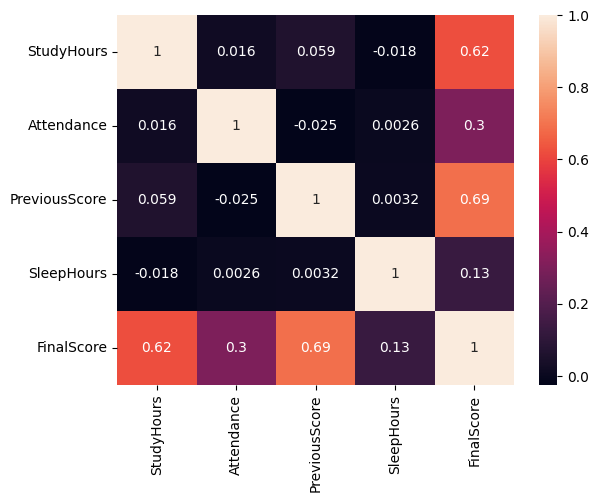

In [49]:
sns.heatmap(corr_matrix, annot=True)

In [50]:
X = df.drop("FinalScore", axis=1)
y = df["FinalScore"]

In [51]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 4)
y shape: (500,)


In [52]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
# Check the shapes

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (400, 4)
X_test Shape : (100, 4)
y_train Shape: (400,)
y_test Shape : (100,)


In [54]:
# Create the Multiple Linear Regression model

model = LinearRegression()

In [55]:
# Train the model using training data

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 0.2854833291245171
Coefficients: [2.18876373 0.22978542 0.45071559 1.05685177]


In [59]:
# Predict FinalScore for the test data

y_pred = model.predict(X_test)
y_pred[:10]


array([63.35202896, 65.10069419, 50.3127409 , 65.29098641, 78.36087879,
       62.35936003, 60.18989089, 64.76687854, 60.78439551, 70.6964744 ])

In [62]:
comparison = pd.DataFrame({
    "Actual Score": y_test.values,
    "Predicted Score": y_pred
})

comparison.head(10)

,Actual Score,Predicted Score
0,64.7,63.352029
1,68.0,65.100694
2,44.3,50.312741
3,70.4,65.290986
4,78.7,78.360879
5,63.2,62.359360
6,65.0,60.189891
7,67.5,64.766879
8,60.9,60.784396
9,68.4,70.696474


In [63]:
# Calculate regression evaluation metrics

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.99198378824715
Mean Squared Error (MSE): 7.048687693713586
Root Mean Squared Error (RMSE): 2.654936476398934
R² Score: 0.897178854669699


# Training vs Testing Performance

After evaluating the model on the test data, we should also check how well the model performs on the training data.

This helps us identify:

- Good Fit
- Underfitting
- Overfitting

A model should perform well on both training and testing data.

### Why do we compare them?

If we only look at the test performance, we may not know whether the model has learned the general pattern or simply memorized the training data.

Therefore, we compare:

- Training R²
- Testing R²

In [64]:
# Predict on training data

y_train_pred = model.predict(X_train)

# Calculate training R²

train_r2 = r2_score(y_train, y_train_pred)

print("Training R² Score:", train_r2)

Training R² Score: 0.930407279390786


In [65]:
r2 = r2_score(y_test, y_pred)
print("Testing R² Score:", r2)

Testing R² Score: 0.897178854669699


In [66]:
print("Training R²:", train_r2)
print("Testing R² :", r2)
print("Difference  :", abs(train_r2 - r2))

Training R²: 0.930407279390786
Testing R² : 0.897178854669699
Difference  : 0.033228424721087


## Model Fit Interpretation

The model achieved the following R² scores:

- **Training R²:** 0.9304
- **Testing R²:** 0.8972
- **Difference:** 0.0332

The training R² is slightly higher than the testing R², which is expected because the model was trained on the training data.

The difference between the training and testing R² scores is approximately **0.0332**, which is relatively small.

Therefore, there is no strong indication of overfitting, and the model appears to generalize reasonably well to unseen data.

### Conclusion

The Multiple Linear Regression model provides a **good fit** for this dataset, with an R² score of approximately **89.72% on the testing data**.

### Saving the Model

In [67]:
import joblib

In [68]:
# Save the trained model

joblib.dump(model, "student_performance_model.pkl")

['student_performance_model.pkl']